# Lab 4 - Solution

## This notebook should be used in conjunction with the Canvas Quiz: Computational Physics Lab 4. Use the notebook to run scripts and make notes. Submit your final answers on Canvas.

# Part I: The stability of the FTCS method applied to 1-D diffusion

These questions examine the stability of the FTCS scheme applied to 1-D diffusion, using the matrix stability method.

diffusion_ftcs.ipynb solves the non-dimensional 1-D heat diffusion equation $\frac{\partial T}{\partial t}=\kappa \frac{\partial^2 T}{\partial x^2} \quad (\kappa > 0)$, where $\kappa$ is the diffusion coefficient, on $0<x<1$ with a $\delta$-function initial condition, and with Dirichlet boundary conditions: $T(x,0)=\delta (x-\tfrac{1}{2} )$ and $\quad T(0,t)=T(1,t)=0.$

The code uses the Forward Time, Centred Space (FTCS) algorithm. As shown in lectures, this method is stable for a choice of time step $\tau$ satisfying the condition$\frac{\kappa \tau}{h^2}<\frac{1}{2}, $ where $h$ is the spatial step. The code animates the numerical solution, and also shows an approximate analytic solution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## <span style="color:red">Q1</span>
### Modify the diffusion_ftcs.ipynb code and match the values of f to the behaviours of the solution

Make the following changes to diffusion_ftcs.ipynb:

1. Allow the user to provide a value of $f = \kappa\tau/h^2$ as an input argument, and then use this to calculate the time step $\tau$ for the values $h=0.05$ and $\kappa=1$, and march forward for 20 time steps.

2. Write code to plot the difference between the numerical temperature profile and the analytic temperature profile at each time step. You can use the existing plotting script with animation, but replace what it plots. To focus on the difference, you should remove the other plots.

3. Set the axis to a fixed vertical range, e.g., after each update: `ax.set(xlim=[0,1], ylim=[-5,5])` so that the plots are comparable to each other at every step.

The code should display different behaviour in each of the following values/ranges for $f$:
- $0 < f < 0.25$
- $0.25 < f < 0.5$
- $f = 0.5$
- $f > 0.5$

In each case study, the behaviour of the numerical solution.

Consider the following values of $f$ in the ranges above. Match each value of $f$ to the best description of the resulting numerical solution:

`f=0.2`, `f=0.45`, `f=0.5`, `f=0.6`

## <span style="color:red">Answer</span>

In [3]:
# the changes to the original diffusion_ftcs are
# -- f introduced as an input argument for easy iteration through values
# -- h, tau are now defined inside the function

def diffusion_ftcs(f, numSteps):
    # Solve the 1-D diffusion equation for an initial spike profile
    # with Dirichlet conditions using FTCS, in a matrix formulation

    # Calculate the ratio tau/(th/2), where th is the approximate diffusion
    # time for one spatial step h
  
    # set the fixed constants as per Q1
    h = 0.05
    kappa = 1
    th = h**2/kappa
    tau = f*h**2/kappa
    print(f"Ratio tau/(0.5*th): {tau/(0.5*th)}")


    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    # Initial conditions, temp0: a spike at x = 1/2
    temp0 = np.zeros((L, 1))
    # Find the index closest to x = 0.5
    idx = np.abs(x - 0.5).argmin()
    temp0[idx] = 1/h
    temp = temp0.copy()  # temp updates across the run

    # Record T(x,t) matrix for visualization
    time = tau * np.arange(numSteps + 1)
    temp_xt = np.zeros((numSteps + 1, L))
    temp_xt[0, :] = temp.flatten()
    
    # Create arrays to store analytical solutions at each step
    temp_an_array = np.zeros((numSteps + 1,L))

    #-------------------------------------------------------------------------------
    # March forwards in time, FTCS style!
    for n in range(numSteps):
        # Update the temperature profile
        temp = A @ temp

        # Recalculate the profile for the (approximate) analytic solution
        sig = np.sqrt(2 * kappa * time[n+1])
        temp_an = np.exp(-((x - 0.5)**2) / (2 * sig**2)) / (np.sqrt(2 * np.pi) * sig)
        
        # Store the analytical solution for this step
        temp_an_array[n+1, :] = temp_an.flatten()

        # Record T(x,t) matrix for visualization
        temp_xt[n+1, :] = temp.flatten()
        
    return x, temp0, temp_an_array, temp_xt, time, tau


Ratio tau/(0.5*th): 0.4


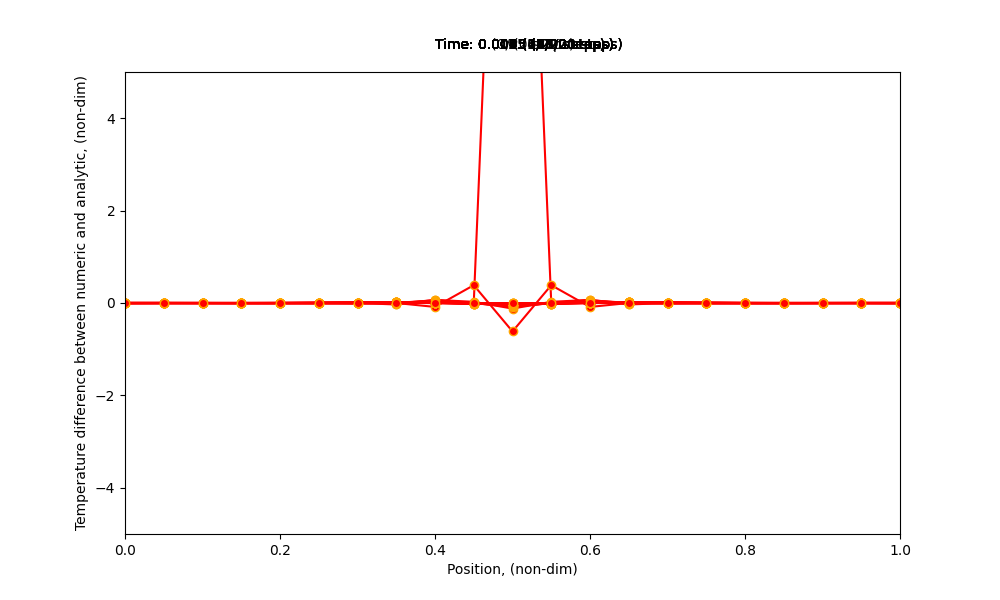

In [5]:
# call the diffusion_ftcs function for different values of f 
# to assess the behaviour of the solution

# define f
f = 0.2
numSteps = 20

# solve for a given f
x, temp0, temp_an_array, temp_numeric, time, tau = diffusion_ftcs(f, numSteps)

#-------------------------------------------------------------------------------
# Plot the results as an animation

%matplotlib widget 
# This enables interactive mode; uncomment and run the following line to go back to static:
# %matplotlib inline
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

ax.set(xlim=[0,1], ylim=[-5,5])


# Plot the numerical solutions interactively
artists = []

for i in range(numSteps+1):
                
    # ------ we are now plotting temp_xt-temp_an!!! ------ #
    plot, = ax.plot(x, temp_numeric[i,:]-temp_an_array[i,:], 'ro-', markeredgecolor='orange')
     
    title = ax.text(0.4, 5.5, f'Time: {i*tau:.2g} ({i}/{numSteps} steps)')    

        
    artists.append([plot, title])
    
ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=300, repeat=False)

ax.set_xlabel('Position, (non-dim)')
ax.set_ylabel('Temperature difference between numeric and analytic, (non-dim)');

We find the following:

| $f$ | Behavior |
|-----|----------|
| 0.2 | converge monotonically |
| 0.45 | converge with oscillation |
| 0.5 | oscillation without convergence |
| 0.6 | diverge |

- For $f < 0.25$ the numerical solution monotonically converges to the asymptotic equilibrium ($t \rightarrow \infty$) solution $T_{eq} = 0$.

- For $f = 0.45$, the behavior is convergent but oscillatory.

- For $f = 0.5$, the behavior is oscillatory but neither convergent nor divergent: the values in the profiles are alternately zero or twice the analytic value.

- For $f = 0.6$ the behavior is divergent and oscillatory.

## <span style="color:red">Q2</span>

As explained in lectures, the stability of the method is dependent on the eigenvalues of the update matrix $\mathrm{A}$, which are defined by the discretisation and by the boundary conditions.

Write new code to do the following:

1. For each value of $f$ from 0 to 1 in steps of $0.05$, calculate the update matrix $\mathrm{A}$. *You already have the code to do this within `diffusion_ftcs`]*

2. For each $f$ value, use the `numpy` function, `np.linalg.eigvals()` (and the `np.max()` and `np.min()` functions) to calculate the following three quantities:

   2.1 The maximum eigenvalue, $\lambda_{\rm max}$, of $\mathrm{A}$;

   2.2 The minimum eigenvalue, $\lambda_{\rm min}$, of $\mathrm{A}$;

   2.3 The magnitude of the dominant eigenvalue, $|\lambda_{\rm dom}|$, (the eigenvalue with the largest magnitude).

3. Plot $\lambda_{\rm min}$, $\lambda_{\rm max}$, and $|\lambda_{\rm dom}|$ as functions of $f$, on one graph, clearly showing individual plotting points using markers (and connecting points using a line).

Produce a single plot with your results, and upload an image of your plot (as a .png or .jpg file).

## <span style="color:red">Answer</span>

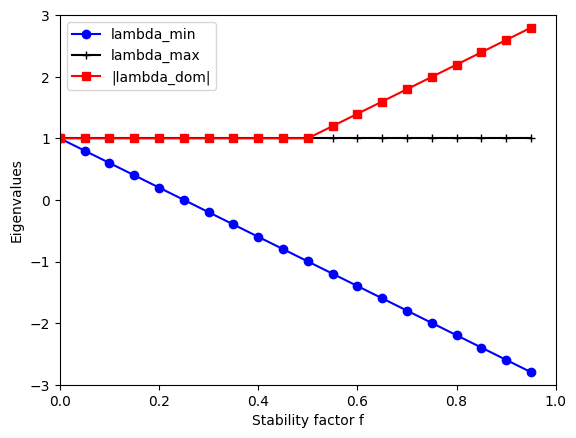

In [6]:
f_array = np.arange(0,1,0.05)
f_num = len(f_array)


# Construct the matrix D associated with the second spatial
# derivative and the boundary conditions, apart from the factor f!
L = 51
D = -2 * np.eye(L)
D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)

# Impose the Dirichlet boundary conditions
D[0, :] = np.zeros(L)
D[L-1, :] = np.zeros(L)

# Initialise:
eMin = np.zeros((f_num,1))
eMax = np.zeros((f_num,1))
eDom = np.zeros((f_num,1))

# Loop over f values
for i in range(f_num):
    
    # Value of f
    f = f_array[i]
    
    # Multiply matrix D by the factor f
    Dp = f*D
    
    # Construct the update matrix
    A = np.eye(L) + Dp
    
    # Extract most positive, most negative, and dominant eigenvalues
    eigenvals = np.linalg.eigvals(A)
    
    eMin[i] = np.min(eigenvals)
    eMax[i] = np.max(eigenvals)
    eDom[i] = np.max(np.abs(eigenvals))
    
# Let's first clear the previous figure though, interactive mode on matplotlib is quite temperamental
# import matplotlib.pyplot as plt
plt.close('all')

# Now, let's plot!
%matplotlib inline

fig, ax = plt.subplots()

ax.plot(f_array, eMin, '-bo', label = 'lambda_min')
ax.plot(f_array, eMax, '-k+', label = 'lambda_max')
ax.plot(f_array, eDom, '-rs', label = '|lambda_dom|')

ax.set(xlim=[0,1], ylim=[-3,3],
      xlabel='Stability factor f', ylabel='Eigenvalues')

ax.legend();

**Marking notes**

- 2 points: correct graph and labels
- 1 point: some issues, e.g., labels missing or scale cut off
- 0 points: incorrect or missing

## <span style="color:red">Q3</span>

<p>As a way to understand the four types of behavior identified in Question 1, we can consider power iteration applied to the initial temperature profile, \({\bf T}^{[0]}\), in terms of an expansion in the eigenvectors of the update matrix, \(\mathrm{A}\):</p>
<p>\({\bf T}^{[0]} = \sum_{i=1}^L C_i{\bf T}^{(i)}\), for constants \(C_i\) and where \({\bf T}^{(i)}\) are the eigenvectors of \(\mathrm{A}\).</p>
<p>Then, after \(m\) power iterations, \({\bf T}^{[m]} = \mathrm{A}^{m}{\bf T}^{[0]} = \sum_{i=1}^{L}C_i\lambda_i^m{\bf T}^{(i)}\), where \({\bf T}^{[j]}\) is the temperature profile at iteration \(j\).</p>
<p>Categorize the numerical behavior of the FTCS numerical scheme across the four relevant ranges of \(f\), and the corresponding conditions on the set of eigenvalues, \(\lambda_i\).</p>

## <span style="color:red">Q4</span>

<p>For each of the four categories above, briefly explain why each range of \(\lambda_i\) yields each qualitative type of algorithmic behavior.</p>

## <span style="color:red"> Answers to Q3, Q4</span>

<p>To understand the observed behavior, consider the initial temperature profile, \(\mathbf{T}^{[0]}\), represented as a sum of the eigenvectors \(\mathbf{T}^{(i)}\):</p>

<p style="text-align:center">\(\mathbf{T}^{[0]} = \sum_{i=1}^{L} C_i\mathbf{T}^{(i)}\).</p>

<p>After \(m\) power iterations:</p>

<p style="text-align:center">\(\mathbf{T}^{[m]} = \mathrm{A}^m \mathbf{T}^{[0]}\) (1)</p>

<p style="text-align:center">\(= \sum_{i=1}^{L}C_i\lambda_i^m\mathbf{T}^{(i)}\), (2)</p>

<p>where \(\mathbf{T}^{[i]}\) is the temperature profile at iteration \(i\).</p>

<p>Based on the plot from question 2, for \(0 < f < 0.25\) we have \(\lambda_{\text{dom}} = 1\). The non-dominant eigenvalues are all positive (\(0 < \lambda_{\text{min}} < 1\)), so the terms involving these eigenvalues in the sum (2) decay monotonically with iteration. This produces monotonic convergence.</p>

<p>For \(0.25 < f < 0.5\), the plot from question 2 shows that again \(\lambda_{\text{dom}} = 1\), but in this case the non-dominant eigenvalues include negative values (\(-1 < \lambda_{\text{min}} < 0\)), so some terms in (2) will alternate in sign with successive iterations. This produces convergence with oscillations.</p>

<p>For \(f = 0.5\) we have \(\lambda_{\text{max}} = 1\) and \(\lambda_{\text{min}} = -1\). There are two dominant eigenvalues. The two terms in (2) corresponding to these eigenvalues persist, i.e., do not decay in size, but the coefficient of \(\lambda_{\text{min}}\) term alternates in sign. This leads to the observed fixed-amplitude oscillation.</p>

<p>For \(f > 0.5\), the plot from question 2 shows that \(\lambda_{\text{dom}} > 1\), in which case the sum (2) grows with iteration - the scheme diverges. Also all non-dominant eigenvalues may be negative, so there are oscillations.</p>

**Marking notes**

Make sure not to penalise for mistakes made in the previous question. Focus on the logic and explanation.

- 2 points: All four cases are correctly explained (bonus: if the matrix form is explained).

- 1 point: if correct but incomplete

- 0 points: completely incorrect or missing

take 0.5 points off for each incorrect/missing case.

# Part II: Solving a different initial value/boundary value problem

These questions involve modifying the diffusion_ftcs.ipynb code to solve a different diffusion problem

Consider the 1-D heat diffusion initial value problem with an initially zero temperature profile: $T(x,0)=0 \quad \text{for}\quad  0<x<1,$ and with boundary conditions $T(0,t)=T(1,t)=1$ for all $t$.

This initial value problem (IVP) describes a thermally conducting rod at some temperature, which suddenly (at time $t=0$) has the temperature of the ends raised (and maintained) at a second, higher temperature.


## <span style="color:red">Q5</span>

<p>The update matrix, \(\mathrm{A}\), for the FTCS scheme for 1-D diffusion with Dirichlet boundary conditions is given by</p>
<p>&nbsp;</p>
<p><img style="display: block; margin-left: auto; margin-right: auto;" src="https://quiz-api-production-s3-uploads-4mqunb7g4o7t.s3.ap-southeast-2.amazonaws.com/item_media/d1c558c5-d73b-4635-b0b0-780a8e6e4c7a/e6494c67-77cd-4ac5-bb84-b5339fdfeff8" alt="" width="419" height="168" /></p>
<p>&nbsp;</p>
<p>The top row and bottom rows in the \(L\times L\) update matrix impose which of the following conditions?</p>

## <span style="color:red">Answer</span>

<p>The top row corresponds to \(T^{n+1}_1 = T^n_1\). The bottom row corresponds to \(T^{n+1}_L = T^n_L\).</p>

## <span style="color:red">Q6</span>

<p>Consider solving the different IVP described.<br /><br />In modifying <code>diffusion_ftcs</code> to solve this new problem, is it necessary to change the update matrix?</p>

## <span style="color:red">Answer</span>

<p>The update matrix applies for any Dirichlet problem. The boundary conditions are enforced by the top and bottom rows together with the initial conditions (the values of \(T^1_1\) and \(T^1_L\)). Hence it is not necessary to change the update matrix, just the initial conditions.</p>

## <span style="color:red">Q7</span>

<p>Modify <code>diffusion_ftcs</code> to solve the new IVP.</p>
<p>Use a spatial step \(h=0.05\), a thermal conductivity \(\kappa=5,\) and a time step \(\tau\) chosen so that \(f = \kappa\tau/h^2 = 0.25\).</p>
<p>Run the code for a large number of time steps (say 1000), until an approximate <em>equilibrium</em> is reached (i.e., the temperature profile is not changing substantially).</p>
<p>(If you're having computational issues, you may speed up the calculation by reducing the frequency of plotting the temperature profile less frequently, e.g., once every 10-50 iterations).</p>
<p>What is the equilibrium solution?</p>


## <span style="color:red">Answer</span>

In [7]:
def diffusion_ftcs_IVP_bothboundaries(tau, h, kappa, numSteps):
    # Solve the IVP using by modifying the diffusion_ftcs method
    # Both right and left BCs = 1 
    
    # Calculate the ratio tau/(th/2), where th is the approximate diffusion
    # time for one spatial step h
    
    th = h**2/kappa
    print(f"Ratio tau/(0.5*th): {tau/(0.5*th)}")

    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    
    ### !!!!! Change initial conditions !!!!! ###
    # Initial conditions with temperature = 1 at both boundaries
    temp0 = np.zeros((L, 1))
    temp0[0] = 1  # Left boundary (x = 0)
    temp0[-1] = 1  # Right boundary (x = 1)
    temp = temp0.copy()  # temp updates across the run

    # Record T(x,t) matrix for visualization
    time = tau * np.arange(numSteps + 1)
    
    temp_xt = np.zeros((numSteps + 1, L))
    temp_xt[0, :] = temp.flatten()

    # We don't need the lines corresponding to the analytic solution
    # (can remove all temp_an mentions)
    
    #-------------------------------------------------------------------------------
    # March forwards in time, FTCS style!
    for n in range(numSteps):
        # Update the temperature profile
        temp = A @ temp

        # Recalculate the profile for the (approximate) analytic solution
        sig = np.sqrt(2 * kappa * time[n+1])

        # Record T(x,t) matrix for visualization
        temp_xt[n+1, :] = temp.flatten()
        
    return x, temp_xt

Ratio tau/(0.5*th): 0.5


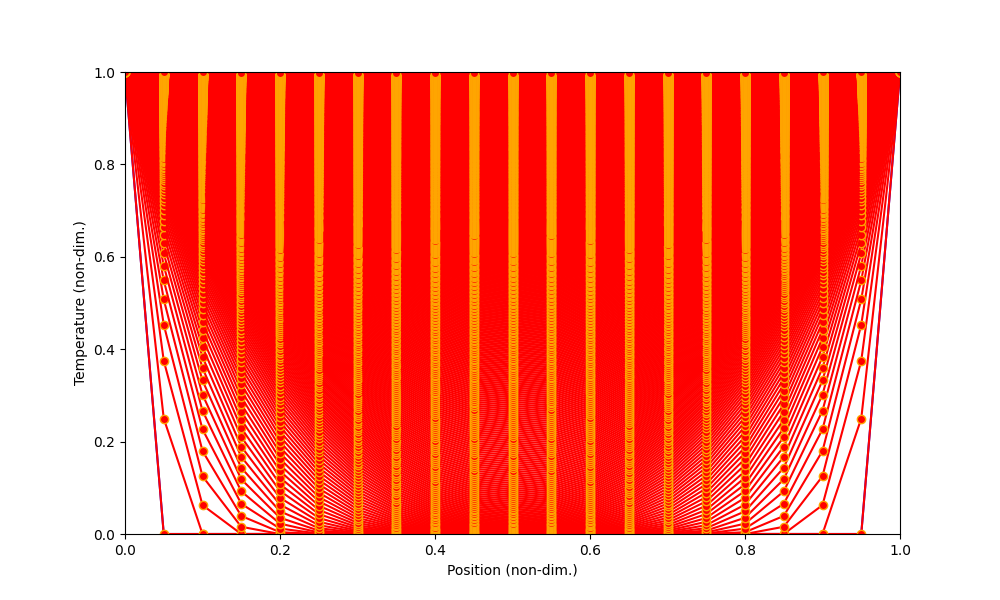

In [8]:
numSteps = 1000
kappa = 5
h = 0.05
f = 0.25

tau = f*h**2/kappa

# call the function
x_both, temp_num_both = diffusion_ftcs_IVP_bothboundaries(tau, h, kappa, numSteps)


# plot outputs

%matplotlib widget 
# This enables interactive mode; uncomment and run the following line to go back to static:
# %matplotlib inline
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

ax.set(xlim=[0,1], ylim=[0,1])


# Plot initial condition
ax.plot(x_both, temp_num_both[0, :], 'b-', linewidth=1.5, label='Initial Profile')

artists = []
for i in range(numSteps+1):

    current_plots = []
    
    main_plot, = ax.plot(x_both, temp_num_both[i, :], 'ro-', markeredgecolor='orange')
    current_plots.append(main_plot)
    
    artists.append(current_plots)
    

ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=0.5, blit=True, repeat=False)


ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Temperature (non-dim.)');
plt.show()

Alternatively, here is the same plot, but static with the temperature profiles shown every 50 time steps:

<Figure size 1000x600 with 0 Axes>

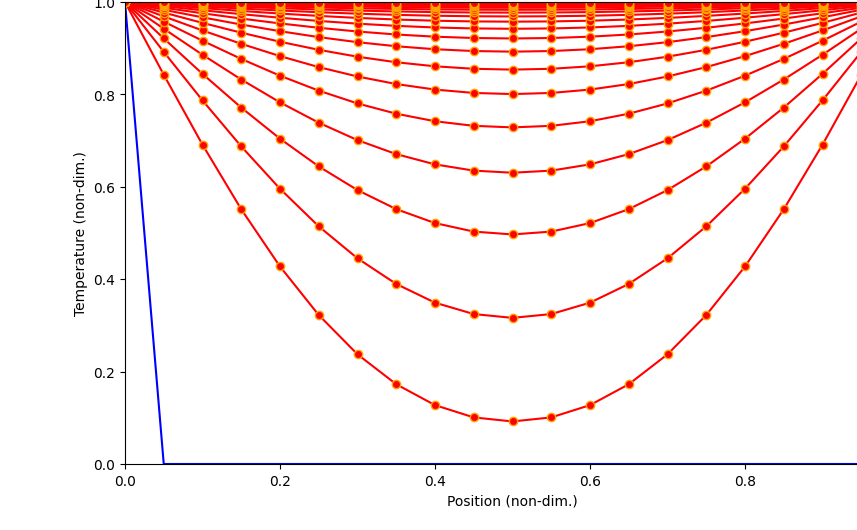

In [9]:
%matplotlib inline 
plt.clf()
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

ax.set(xlim=[0,1], ylim=[0,1])


# Plot initial condition
ax.plot(x_both, temp_num_both[0, :], 'b-', linewidth=1.5, label='Initial Profile')


# Plot intermediate snapshots every 50 steps
for i in range(50, numSteps+1, 50):
    plt.plot(x_both, temp_num_both[i, :], 'ro-', markeredgecolor='orange')


ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Temperature (non-dim.)');

We can clearly see system approaching an equilibrium, $T(x)$ = 1.

## <span style="color:red">Q8</span>

<p>Provide an analytic explanation for the equilibrium found numerically in Question 6:</p>
<ol>
<li>Setting \(\partial T/\partial t = 0\) in the 1-D diffusion PDE gives a simple ODE describing the equilibrium situation: \[\frac{d^2T_{\rm eq}}{dx^2}=0,\] where \(T_{\rm eq}(x)\) is the equilibrium temperature profile.</li>
<li>By integrating this ODE analytically, and imposing the boundary conditions \(T(0,t) = T(1,t) = 1\) for all \(t\), obtain an analytic expression for the equilibrium temperature profile.&nbsp;</li>
</ol>
<p><strong>Briefly summarize your steps..</strong></p>

## <span style="color:red">Answer</span>

<p>Integrating \(d^2T_{eq}/dx^2 = 0\) gives</p>

<p style="text-align:center">\(T_{eq}(x) = Ax + B\), (3)</p>

<p>for constants \(A\) and \(B\). Applying the boundary conditions, \(T_{eq}(0) = T_{eq}(1) = 1\) gives \(A = 0\) and \(B = 1\), which leads to \(T_{eq}(x) = 1\), matching the numerical result in Question 6.</p>


**Marking notes**

- 2 points: all key steps demonstrated, including Eq. 3 and application of the boundary conditions
- 1 point: correct thinking, but some missing or incorrect steps
- 0 points: incorrect or missing

## <span style="color:red">Q9</span>

<p>Consider the case that the temperature profile is again&nbsp;zero initially for \(0&lt;x&lt;1\) but the BCs are changed to \[T(0,t)=0\quad \text{and}\quad T(1,t)=1\]&nbsp;for all \(t.\)</p>
<p>&nbsp;</p>
<p>Following the same reasoning as Question 7, make a prediction about what the equilibrium solution will look like.</p>
<p>&nbsp;</p>
<p>Modify the initial conditions from your code from Question 6 and run it to confirm your prediction.<br /><br /><strong>Upload a clear image of your FINAL EQUILIBRIUM TEMPERATURE PROFILE plot.</strong></p>

## <span style="color:red">Answer</span>

In [12]:
def diffusion_ftcs_IVP_rightboundary(tau, h, kappa, numsteps):
    # Solve the IVP using by modifying the diffusion_ftcs method
    
    # Calculate the ratio tau/(th/2), where th is the approximate diffusion
    # time for one spatial step h
    
    th = h**2/kappa
    print(f"Ratio tau/(0.5*th): {tau/(0.5*th)}")

    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    
    ### !!!!! Change initial conditions !!!!! ###
    # Initial conditions with temperature = 0 at left
    # and 1 at right boundary
    temp0 = np.zeros((L, 1))
    temp0[0] = 0  # Left boundary (x = 0)
    temp0[-1] = 1  # Right boundary (x = 1)
    temp = temp0.copy()  # temp updates across the run

    # Record T(x,t) matrix for visualization
    time = tau * np.arange(numSteps + 1)
    
    temp_xt = np.zeros((numSteps + 1, L))
    temp_xt[0, :] = temp.flatten()

    # We don't need the lines corresponding to the analytic solution
    # (can remove all temp_an mentions)
    
    #-------------------------------------------------------------------------------
    # March forwards in time, FTCS style!
    for n in range(numSteps):
        # Update the temperature profile
        temp = A @ temp

        # Recalculate the profile for the (approximate) analytic solution
        sig = np.sqrt(2 * kappa * time[n+1])

        # Record T(x,t) matrix for visualization
        temp_xt[n+1, :] = temp.flatten()
        
    return x, temp_xt


Ratio tau/(0.5*th): 0.5


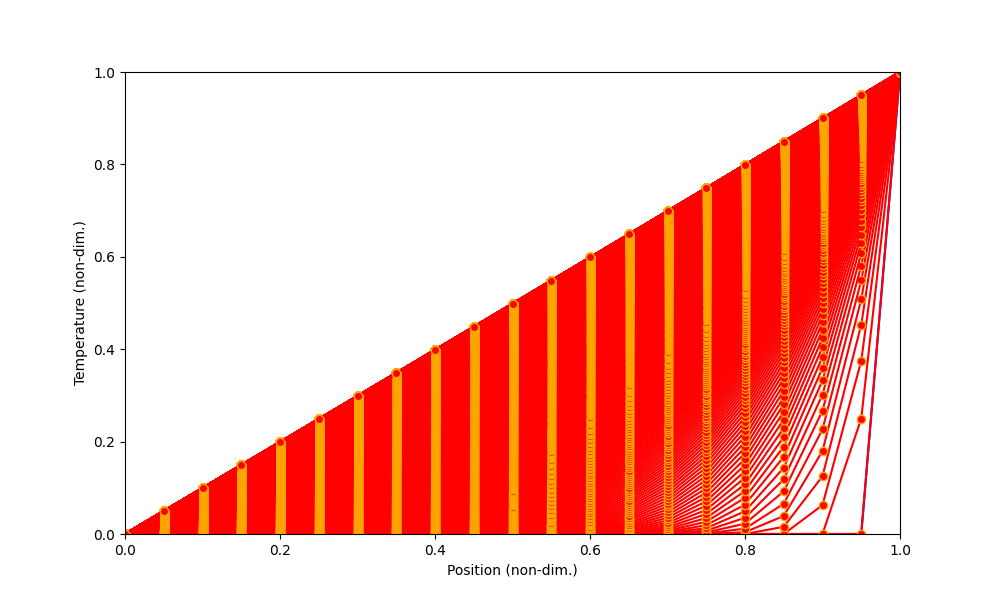

In [13]:

numSteps = 1000
kappa = 5
h = 0.05
f = 0.25

tau = f*h**2/kappa

x_right, temp_num_right = diffusion_ftcs_IVP_rightboundary(tau, h, kappa, numSteps)



%matplotlib widget 
# This enables interactive mode; uncomment and run the following line to go back to static:
# %matplotlib inline
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

ax.set(xlim=[0,1], ylim=[0,1])


# Plot initial condition
ax.plot(x_right, temp_num_right[0, :], 'b-', linewidth=1.5, label='Initial Profile')

artists = []
for i in range(numSteps+1):

    current_plots = []
    
    main_plot, = ax.plot(x_right, temp_num_right[i, :], 'ro-', markeredgecolor='orange')
    current_plots.append(main_plot)
    
    artists.append(current_plots)
    

ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=10, blit=True, repeat=False)


ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Temperature (non-dim.)');
plt.show()

Alternatively, here is the same plot, but static with the temperature profiles shown every 50 time steps:

<Figure size 640x480 with 0 Axes>

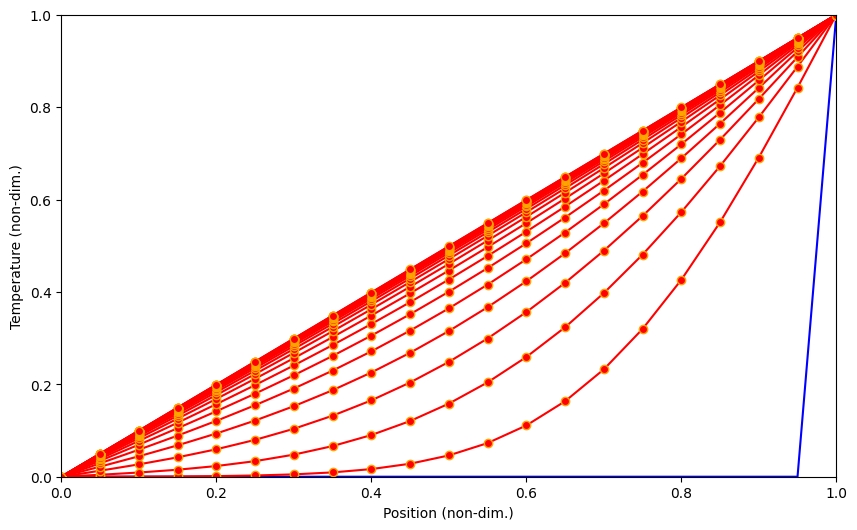

In [15]:
%matplotlib inline 
plt.clf()
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

ax.set(xlim=[0,1], ylim=[0,1])


# Plot initial condition
ax.plot(x_right, temp_num_right[0, :], 'b-', linewidth=1.5, label='Initial Profile')


# Plot intermediate snapshots every 50 steps
for i in range(50, numSteps+1, 50):
    plt.plot(x_right, temp_num_right[i, :], 'ro-', markeredgecolor='orange')


ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Temperature (non-dim.)');

And, just the final profile, which is close to the analytic solution $T=x$:

<Figure size 640x480 with 0 Axes>

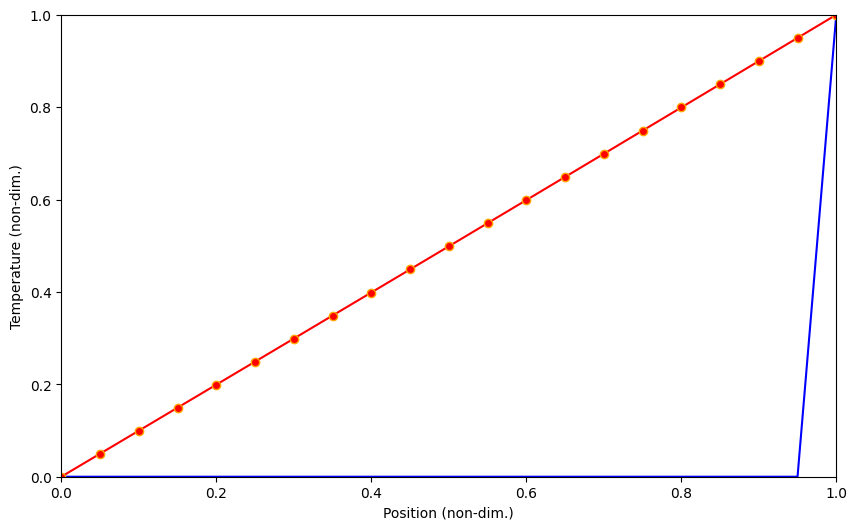

In [16]:
%matplotlib inline 
plt.clf()
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

ax.set(xlim=[0,1], ylim=[0,1])


# Plot initial condition
ax.plot(x_right, temp_num_right[0, :], 'b-', linewidth=1.5, label='Initial Profile')


# Plot final profile
ax.plot(x_right, temp_num_right[-1, :], 'ro-', linewidth=1.5, markeredgecolor='orange', label='Final temperature Profile')

ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Temperature (non-dim.)');


<p>In this case imposing <span>T<sub>eq</sub>(0) = 0</span> and <span>T<sub>eq</sub>(1) = 1</span> on Equation (3) gives <span>A = 1</span> and <span>B = 0</span>, i.e., the steady state is <span>T<sub>eq</sub>(x) = x</span>, as we obtained numerically.</p>

**Marking notes**

- 1 point: correct graph and labels
- 0.5 point: some issues, e.g., missing labels or dimensional units
- 0 points: incorrect or missing plot